In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
sys.path.append("../")
from diabnet.apply_ensemble import Predictor
from diabnet.data import get_feature_names
from diabnet.ensemble import Ensemble

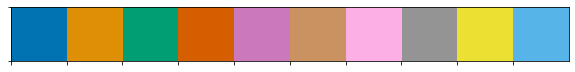

In [4]:
colors = sns.color_palette("colorblind")
sns.palplot(colors)
sns.set_style("whitegrid")
sns.set_style("ticks",{'axes.grid': True,'grid.color': '.95', 'grid.linestyle': '-'})

In [5]:
ensemble = Ensemble('../diabnet/models/model-6-soft-label-age-positives-1000-dropout0-bn-decay-flood-hyperopt-batch256-adamw-lc1-20200914')
c = get_feature_names("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv", BMI=False, sex=True, parents_diagnostics=True)
pred = Predictor(ensemble, c, "../datasets/visits_sp_unique_test_positivo_1000_random_0_negatives_older60.csv")

../diabnet/models/model-6-soft-label-age-positives-1000-dropout0-bn-decay-flood-hyperopt-batch256-adamw-lc1-20200914
NEGATIVE FILE ../datasets/visits_sp_unique_test_positivo_1000_random_0_negatives_older60.csv


In [6]:
df = pd.read_csv("../datasets/visits_sp_unique_test_positivo_1000_random_0.csv")

## Qual o efeito da idade?

Grupos:
- todos os pacientes
- controle negativo (negativos >60yo)
- positivos

Valores:
- y => Pt/P(t-1)
- x => 20>t>80 

In [7]:
features = df[c].values

In [8]:
for age in range(20,85, 5):
    probs = [np.mean(pred.patient(pat_feat, age=age, samples_per_model=1)) for pat_feat in features]
    df[f"pred_age_{age}"] = probs
    

In [9]:
df

,Unnamed: 0,id,snp_8_133462953,snp_2_91635413,snp_9_25963828,snp_1_17764169,snp_12_41767967,snp_4_49530811,snp_2_96519717,snp_7_116910447,...,pred_age_35,pred_age_40,pred_age_45,pred_age_50,pred_age_55,pred_age_60,pred_age_65,pred_age_70,pred_age_75,pred_age_80
0,0,A11123,0,0,0,0,0,0,0,0,...,0.828714,0.871941,0.907890,0.936363,0.957680,0.972726,0.982767,0.989152,0.993059,0.995378
1,1,A00551,0,0,0,1,0,1,1,0,...,0.065758,0.065170,0.065723,0.067588,0.071091,0.076759,0.085325,0.097672,0.114678,0.136974
2,2,A02267,0,0,0,0,0,1,0,0,...,0.177986,0.194168,0.216283,0.245538,0.283050,0.329537,0.385011,0.448595,0.518509,0.592258
3,3,A00586,0,0,0,0,0,1,0,0,...,0.059874,0.054546,0.050352,0.047400,0.045831,0.045851,0.047770,0.052055,0.059397,0.070783
4,4,A16039,0,0,0,0,0,1,0,0,...,0.055502,0.050785,0.046649,0.043150,0.040349,0.038303,0.037079,0.036759,0.037448,0.039292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,545,A02889,0,2,0,1,0,1,1,0,...,0.081263,0.083037,0.086150,0.090805,0.097264,0.105870,0.117052,0.131289,0.149061,0.170839
546,546,A26102,0,0,0,0,0,0,0,0,...,0.116999,0.129906,0.149012,0.176002,0.212698,0.260687,0.320763,0.392459,0.473802,0.561165
547,547,A03220,0,0,1,0,0,0,0,0,...,0.016383,0.014373,0.012757,0.011511,0.010619,0.010077,0.009898,0.010123,0.010828,0.012152
548,548,A39026,0,0,1,1,0,1,1,0,...,0.170428,0.182770,0.198675,0.218731,0.243431,0.273156,0.308120,0.348236,0.393058,0.441820


In [10]:
for age in range(25,85, 5):
    df[f"pred_diff_ages_{age}-{age-5}"] = df[f"pred_age_{age}"] - df[f"pred_age_{age-5}"]

In [11]:
df2 = df.filter(regex='pred_diff')

In [12]:
df3 = df.filter(regex='pred_diff').describe().transpose()
df4 = df[df.T2D == 1].filter(regex='pred_diff').describe().transpose()
df5 = df[(df.T2D == 0) & (df.AGE > 60)].filter(regex='pred_diff').describe().transpose()

In [13]:
df2

,pred_diff_ages_25-20,pred_diff_ages_30-25,pred_diff_ages_35-30,pred_diff_ages_40-35,pred_diff_ages_45-40,pred_diff_ages_50-45,pred_diff_ages_55-50,pred_diff_ages_60-55,pred_diff_ages_65-60,pred_diff_ages_70-65,pred_diff_ages_75-70,pred_diff_ages_80-75
0,0.058805,0.055347,0.049882,0.043228,0.035949,0.028473,0.021317,0.015045,0.010041,0.006385,0.003906,2.319753e-03
1,-0.003426,-0.002583,-0.001631,-0.000588,0.000553,0.001865,0.003503,0.005668,0.008566,0.012347,0.017005,2.229588e-02
2,0.004133,0.007386,0.011339,0.016182,0.022115,0.029255,0.037512,0.046487,0.055474,0.063583,0.069915,7.374853e-02
3,-0.008183,-0.007322,-0.006369,-0.005328,-0.004194,-0.002952,-0.001569,0.000020,0.001919,0.004285,0.007342,1.138623e-02
4,-0.006078,-0.005689,-0.005235,-0.004717,-0.004137,-0.003498,-0.002802,-0.002046,-0.001224,-0.000320,0.000689,1.844320e-03
...,...,...,...,...,...,...,...,...,...,...,...,...
545,-0.001226,-0.000382,0.000614,0.001775,0.003112,0.004656,0.006459,0.008606,0.011182,0.014237,0.017772,2.177821e-02
546,0.001417,0.004352,0.008093,0.012907,0.019106,0.026990,0.036696,0.047988,0.060077,0.071696,0.081343,8.736268e-02
547,-0.003385,-0.002890,-0.002433,-0.002009,-0.001616,-0.001246,-0.000892,-0.000542,-0.000178,0.000225,0.000705,1.323966e-03
548,0.004996,0.007002,0.009399,0.012342,0.015905,0.020056,0.024699,0.029725,0.034963,0.040117,0.044822,4.876181e-02


<AxesSubplot:ylabel='mean'>

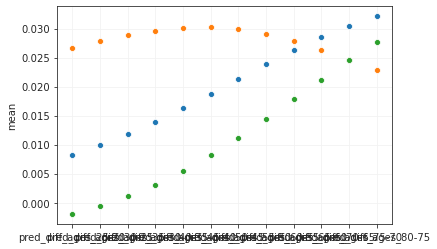

In [14]:
sns.scatterplot(y='mean', x=df3.index, data=df3)
sns.scatterplot(y='mean', x=df4.index, data=df4)
sns.scatterplot(y='mean', x=df5.index, data=df5)

<AxesSubplot:>

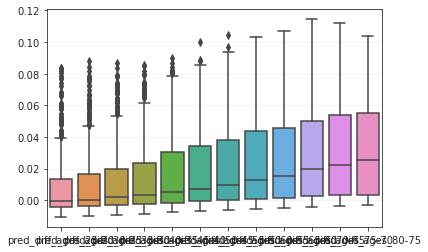

In [15]:
sns.boxplot(data=df2)

<AxesSubplot:>

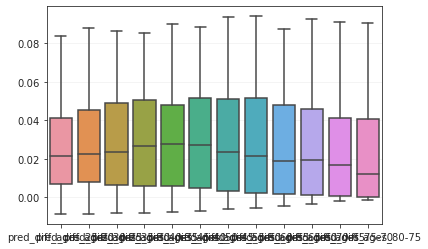

In [16]:
sns.boxplot(data=df[df.T2D == 1].filter(regex='pred_diff'))

<AxesSubplot:>

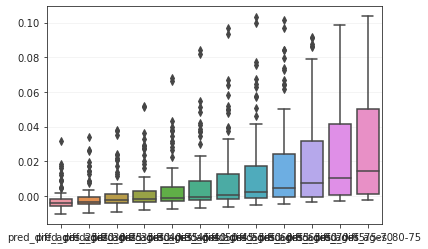

In [17]:
sns.boxplot(data=df[(df.T2D == 0) & (df.AGE > 60)].filter(regex='pred_diff'))